Cell 1 — Setup path dan konfigurasi

In [3]:
from pathlib import Path
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt

# =========================
# CONFIG
# =========================

FRAMED_BASE_DIR = Path("/media/spell/Spell-lab/Lidar/C.Framed Dataset")

DEV_DIR = FRAMED_BASE_DIR / "Dataset Development"
TEST_DIR = FRAMED_BASE_DIR / "Dataset Testing"

FIG_DIR = FRAMED_BASE_DIR / "_analysis_figures"
FIG_DIR.mkdir(parents=True, exist_ok=True)

ACTIVITIES = ["Bungkuk", "Duduk", "Jongkok", "Jatuh"]

DEV_SUBJECTS = [
    "Adelia",
    "Afi",
    "Aswangga",
    "Bustan",
    "Dilia",
    "Eldivo",
    "Fathir",
    "Lina",
    "Manda",
    "Miftah",
    "Teguh",
    "Tsamara",
]

TEST_ROOMS = ["Controlled Room", "Uncontrolled Room"]

TEST_SUBJECTS = [
    "Kanaya",
    "Naila",
    "Nana",
    "Rega",
    "Zaira",
]

FILES = [f"{i}.csv" for i in range(1, 10)]

EXPECTED_POINT_PER_PACKET = 96
EXPECTED_PACKET_PER_FRAME = 208
EXPECTED_POINT_PER_FRAME = EXPECTED_POINT_PER_PACKET * EXPECTED_PACKET_PER_FRAME
EXPECTED_TIMESTAMP_DIFF_NS = 480000

print("===== FRAME BUILDER ANALYSIS CONFIG =====")
print("Framed base dir:", FRAMED_BASE_DIR)
print("Development dir exists:", DEV_DIR.exists())
print("Testing dir exists    :", TEST_DIR.exists())
print("Figure output dir     :", FIG_DIR)

print("\nExpected point per packet :", EXPECTED_POINT_PER_PACKET)
print("Expected packet per frame :", EXPECTED_PACKET_PER_FRAME)
print("Expected point per frame  :", EXPECTED_POINT_PER_FRAME)
print("Expected timestamp diff ns:", EXPECTED_TIMESTAMP_DIFF_NS)

===== FRAME BUILDER ANALYSIS CONFIG =====
Framed base dir: /media/spell/Spell-lab/Lidar/C.Framed Dataset
Development dir exists: True
Testing dir exists    : True
Figure output dir     : /media/spell/Spell-lab/Lidar/C.Framed Dataset/_analysis_figures

Expected point per packet : 96
Expected packet per frame : 208
Expected point per frame  : 19968
Expected timestamp diff ns: 480000


Cell 2 — Build daftar semua file framed

In [4]:
# =========================
# COLLECT ALL FRAMED FILE PATHS
# =========================

records = []

# Development files
for activity in ACTIVITIES:
    for subject in DEV_SUBJECTS:
        for file_name in FILES:
            path = DEV_DIR / activity / subject / file_name
            records.append({
                "dataset_type": "development",
                "room": None,
                "activity": activity,
                "subject": subject,
                "file_name": file_name,
                "path": str(path),
                "exists": path.exists(),
            })

# Testing files
for room in TEST_ROOMS:
    for activity in ACTIVITIES:
        for subject in TEST_SUBJECTS:
            for file_name in FILES:
                path = TEST_DIR / room / activity / subject / file_name
                records.append({
                    "dataset_type": "testing",
                    "room": room,
                    "activity": activity,
                    "subject": subject,
                    "file_name": file_name,
                    "path": str(path),
                    "exists": path.exists(),
                })

files_df = pd.DataFrame(records)

print("===== FRAMED FILE INVENTORY =====")
print("Total expected files:", len(files_df))
print("Existing files      :", int(files_df["exists"].sum()))
print("Missing files       :", int((~files_df["exists"]).sum()))

print("\nSummary by dataset type:")
display(
    files_df.groupby("dataset_type")["exists"]
    .agg(expected="count", found="sum")
    .assign(missing=lambda x: x["expected"] - x["found"])
    .reset_index()
)

print("\nMissing files preview:")
display(files_df[files_df["exists"] == False].head(30))

===== FRAMED FILE INVENTORY =====
Total expected files: 792
Existing files      : 792
Missing files       : 0

Summary by dataset type:


,dataset_type,expected,found,missing
0,development,432,432,0
1,testing,360,360,0



Missing files preview:


,dataset_type,room,activity,subject,file_name,path,exists


Cell 3 — Hitung statistik global frame builder dari semua file

In [5]:
# =========================
# GLOBAL FRAME BUILDER STATISTICS
# =========================

all_point_per_packet = []
all_timestamp_diff = []
all_packet_per_frame = []
all_point_per_frame = []

file_summary_records = []

existing_files = files_df[files_df["exists"] == True].copy()

for idx, row in existing_files.iterrows():
    path = Path(row["path"])
    
    summary = {
        "dataset_type": row["dataset_type"],
        "room": row["room"],
        "activity": row["activity"],
        "subject": row["subject"],
        "file_name": row["file_name"],
        "path": row["path"],
        "can_read": False,
        "num_rows": None,
        "num_frames": None,
        "point_per_packet_min": None,
        "point_per_packet_median": None,
        "point_per_packet_max": None,
        "timestamp_diff_median_ns": None,
        "timestamp_diff_unique_count": None,
        "packet_per_frame_min": None,
        "packet_per_frame_median": None,
        "packet_per_frame_max": None,
        "point_per_frame_min": None,
        "point_per_frame_median": None,
        "point_per_frame_max": None,
        "error": None,
    }
    
    try:
        df = pd.read_csv(path)
        summary["can_read"] = True
        summary["num_rows"] = len(df)
        
        required_cols = ["frame_id", "Timestamp", "X", "Y", "Z", "Reflectivity"]
        missing_cols = [c for c in required_cols if c not in df.columns]
        if missing_cols:
            summary["error"] = f"Missing columns: {missing_cols}"
            file_summary_records.append(summary)
            continue
        
        # Ensure numeric for analysis only
        df["frame_id"] = pd.to_numeric(df["frame_id"], errors="coerce")
        df["Timestamp"] = pd.to_numeric(df["Timestamp"], errors="coerce")
        df = df.dropna(subset=["frame_id", "Timestamp"]).copy()
        df["frame_id"] = df["frame_id"].astype(int)
        
        # 1) point per packet = row count per unique timestamp
        ppp = df.groupby("Timestamp").size().to_numpy()
        all_point_per_packet.extend(ppp.tolist())
        
        summary["point_per_packet_min"] = int(np.min(ppp))
        summary["point_per_packet_median"] = float(np.median(ppp))
        summary["point_per_packet_max"] = int(np.max(ppp))
        
        # 2) timestamp diff
        unique_ts = np.sort(df["Timestamp"].unique())
        if len(unique_ts) >= 2:
            ts_diff = np.diff(unique_ts)
            all_timestamp_diff.extend(ts_diff.tolist())
            summary["timestamp_diff_median_ns"] = float(np.median(ts_diff))
            summary["timestamp_diff_unique_count"] = int(pd.Series(ts_diff).nunique())
        
        # 3) packet per frame = unique timestamp count per frame
        ppf = df.groupby("frame_id")["Timestamp"].nunique().to_numpy()
        all_packet_per_frame.extend(ppf.tolist())
        
        summary["packet_per_frame_min"] = int(np.min(ppf))
        summary["packet_per_frame_median"] = float(np.median(ppf))
        summary["packet_per_frame_max"] = int(np.max(ppf))
        
        # 4) point per frame = row count per frame
        ptf = df.groupby("frame_id").size().to_numpy()
        all_point_per_frame.extend(ptf.tolist())
        
        summary["num_frames"] = int(df["frame_id"].nunique())
        summary["point_per_frame_min"] = int(np.min(ptf))
        summary["point_per_frame_median"] = float(np.median(ptf))
        summary["point_per_frame_max"] = int(np.max(ptf))
        
    except Exception as e:
        summary["error"] = str(e)
    
    file_summary_records.append(summary)
    
    if (len(file_summary_records) % 100 == 0) or (len(file_summary_records) == len(existing_files)):
        print(f"Analyzed {len(file_summary_records)}/{len(existing_files)} files...")

file_summary_df = pd.DataFrame(file_summary_records)

all_point_per_packet = np.array(all_point_per_packet)
all_timestamp_diff = np.array(all_timestamp_diff)
all_packet_per_frame = np.array(all_packet_per_frame)
all_point_per_frame = np.array(all_point_per_frame)

print("===== GLOBAL ANALYSIS SUMMARY =====")
print("Readable files:", int(file_summary_df["can_read"].sum()), "/", len(file_summary_df))

print("\nGlobal point per packet:")
print(pd.Series(all_point_per_packet).describe())

print("\nGlobal timestamp diff ns:")
print(pd.Series(all_timestamp_diff).describe())

print("\nGlobal packet per frame:")
print(pd.Series(all_packet_per_frame).describe())

print("\nGlobal point per frame:")
print(pd.Series(all_point_per_frame).describe())

print("\nFiles with error:")
display(file_summary_df[file_summary_df["error"].notna()].head(30))

Analyzed 100/792 files...
Analyzed 200/792 files...
Analyzed 300/792 files...
Analyzed 400/792 files...
Analyzed 500/792 files...
Analyzed 600/792 files...
Analyzed 700/792 files...
Analyzed 792/792 files...
===== GLOBAL ANALYSIS SUMMARY =====
Readable files: 792 / 792

Global point per packet:
count    9853168.0
mean          96.0
std            0.0
min           96.0
25%           96.0
50%           96.0
75%           96.0
max           96.0
dtype: float64

Global timestamp diff ns:
count    9.852376e+06
mean     4.800199e+05
std      6.322580e+02
min      4.800000e+05
25%      4.800000e+05
50%      4.800000e+05
75%      4.800000e+05
max      5.200000e+05
dtype: float64

Global packet per frame:
count    47371.0
mean       208.0
std          0.0
min        208.0
25%        208.0
50%        208.0
75%        208.0
max        208.0
dtype: float64

Global point per frame:
count    47371.0
mean     19968.0
std          0.0
min      19968.0
25%      19968.0
50%      19968.0
75%      19968.

,dataset_type,room,activity,subject,file_name,path,can_read,num_rows,num_frames,point_per_packet_min,...,point_per_packet_max,timestamp_diff_median_ns,timestamp_diff_unique_count,packet_per_frame_min,packet_per_frame_median,packet_per_frame_max,point_per_frame_min,point_per_frame_median,point_per_frame_max,error


Cell 4 — Histogram point per packet

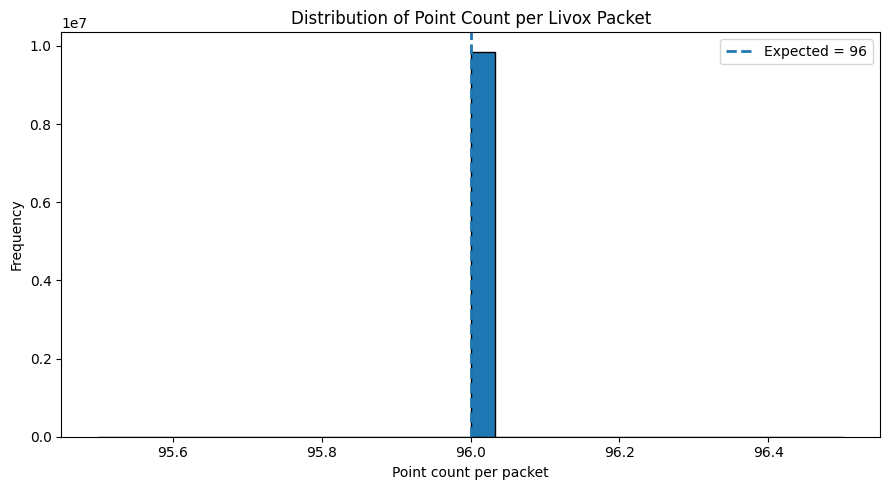

Saved figure: /media/spell/Spell-lab/Lidar/C.Framed Dataset/_analysis_figures/hist_point_per_packet.png
Unique point-per-packet values:


,point_per_packet,count
0,96,9853168


In [6]:
# =========================
# PLOT 1: HISTOGRAM POINT PER PACKET
# =========================

plt.figure(figsize=(9, 5))
plt.hist(all_point_per_packet, bins=30, edgecolor="black")
plt.axvline(EXPECTED_POINT_PER_PACKET, linestyle="--", linewidth=2, label=f"Expected = {EXPECTED_POINT_PER_PACKET}")
plt.xlabel("Point count per packet")
plt.ylabel("Frequency")
plt.title("Distribution of Point Count per Livox Packet")
plt.legend()
plt.tight_layout()

fig_path = FIG_DIR / "hist_point_per_packet.png"
plt.savefig(fig_path, dpi=300, bbox_inches="tight")
plt.show()

print("Saved figure:", fig_path)
print("Unique point-per-packet values:")
display(pd.Series(all_point_per_packet).value_counts().sort_index().reset_index().rename(columns={"index": "point_per_packet", 0: "count"}).head(20))

Cell 5 — Histogram timestamp diff

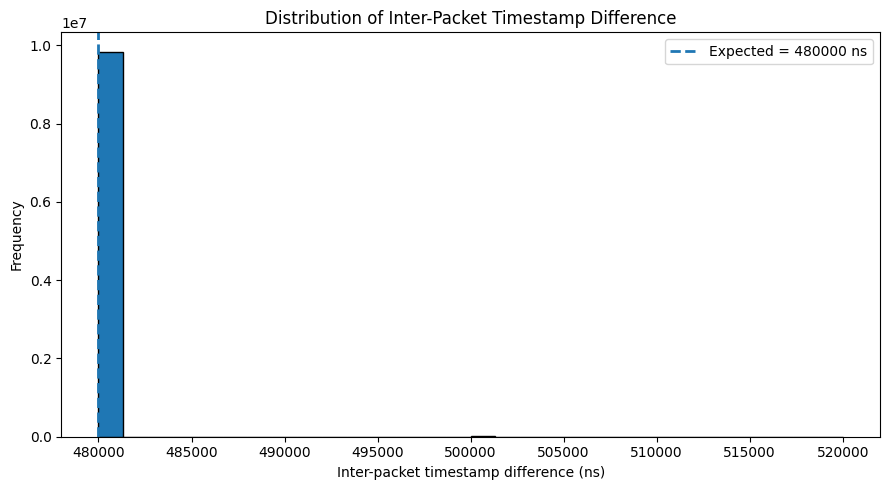

Saved figure: /media/spell/Spell-lab/Lidar/C.Framed Dataset/_analysis_figures/hist_timestamp_diff_ns.png
Unique timestamp diff values:


,timestamp_diff_ns,count
0,480000,9842580
1,500000,9776
2,520000,20


In [7]:
# =========================
# PLOT 2: HISTOGRAM TIMESTAMP DIFF
# =========================

plt.figure(figsize=(9, 5))
plt.hist(all_timestamp_diff, bins=30, edgecolor="black")
plt.axvline(EXPECTED_TIMESTAMP_DIFF_NS, linestyle="--", linewidth=2, label=f"Expected = {EXPECTED_TIMESTAMP_DIFF_NS} ns")
plt.xlabel("Inter-packet timestamp difference (ns)")
plt.ylabel("Frequency")
plt.title("Distribution of Inter-Packet Timestamp Difference")
plt.legend()
plt.tight_layout()

fig_path = FIG_DIR / "hist_timestamp_diff_ns.png"
plt.savefig(fig_path, dpi=300, bbox_inches="tight")
plt.show()

print("Saved figure:", fig_path)
print("Unique timestamp diff values:")
display(pd.Series(all_timestamp_diff).value_counts().sort_index().reset_index().rename(columns={"index": "timestamp_diff_ns", 0: "count"}).head(20))

Cell 6 — Pilih file contoh representatif untuk line plot

In [8]:
# =========================
# SELECT REPRESENTATIVE FILE FOR LINE PLOTS
# =========================

preferred_example = {
    "dataset_type": "development",
    "room": None,
    "activity": "Jatuh",
    "subject": "Adelia",
    "file_name": "1.csv",
}

candidate_df = files_df[
    (files_df["exists"] == True) &
    (files_df["dataset_type"] == preferred_example["dataset_type"]) &
    (files_df["activity"] == preferred_example["activity"]) &
    (files_df["subject"] == preferred_example["subject"]) &
    (files_df["file_name"] == preferred_example["file_name"])
].copy()

if len(candidate_df) == 0:
    print("Preferred example not found. Using first existing framed file.")
    example_row = files_df[files_df["exists"] == True].iloc[0]
else:
    example_row = candidate_df.iloc[0]

EXAMPLE_PATH = Path(example_row["path"])

print("===== SELECTED EXAMPLE FILE =====")
print("Dataset type:", example_row["dataset_type"])
print("Room        :", example_row["room"])
print("Activity    :", example_row["activity"])
print("Subject     :", example_row["subject"])
print("File        :", example_row["file_name"])
print("Path        :", EXAMPLE_PATH)
print("Exists      :", EXAMPLE_PATH.exists())

example_df = pd.read_csv(EXAMPLE_PATH)
print("\nExample dataframe shape:", example_df.shape)
print("Columns:", example_df.columns.tolist())
display(example_df.head())

===== SELECTED EXAMPLE FILE =====
Dataset type: development
Room        : None
Activity    : Jatuh
Subject     : Adelia
File        : 1.csv
Path        : /media/spell/Spell-lab/Lidar/C.Framed Dataset/Dataset Development/Jatuh/Adelia/1.csv
Exists      : True

Example dataframe shape: (1198080, 6)
Columns: ['frame_id', 'Timestamp', 'X', 'Y', 'Z', 'Reflectivity']


,frame_id,Timestamp,X,Y,Z,Reflectivity
0,0,5015632492940,2.207,-1.282,2.457,71.0
1,0,5015632492940,2.355,-1.255,2.196,86.0
2,0,5015632492940,2.419,-1.246,2.079,93.0
3,0,5015632492940,2.223,-1.229,2.444,74.0
4,0,5015632492940,2.292,-1.212,2.304,90.0


Cell 7 — Line plot point per frame untuk file contoh

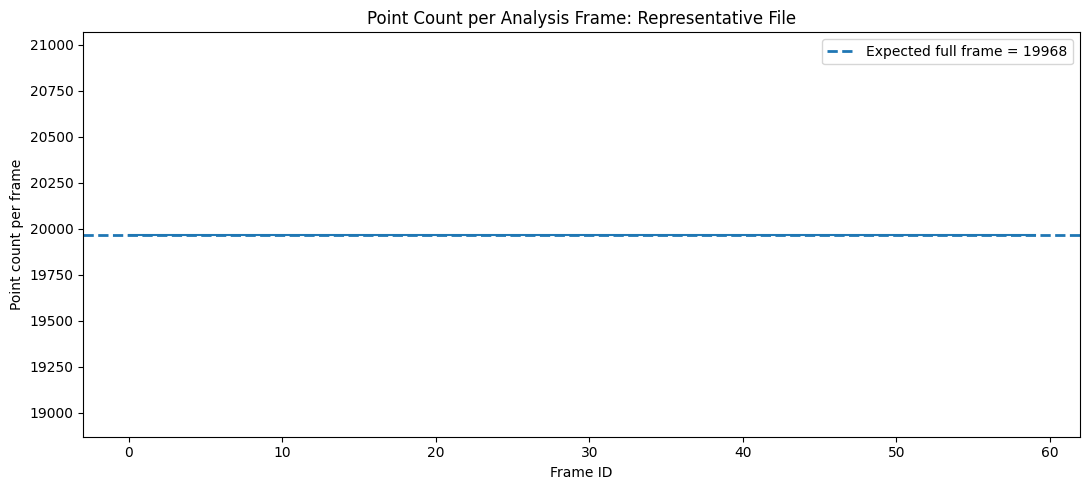

Saved figure: /media/spell/Spell-lab/Lidar/C.Framed Dataset/_analysis_figures/line_point_per_frame_example.png
Point per frame summary for example file:


count       60.0
mean     19968.0
std          0.0
min      19968.0
25%      19968.0
50%      19968.0
75%      19968.0
max      19968.0
Name: point_count, dtype: float64


Unique point count per frame:


,point_count,count
0,19968,60


In [9]:
# =========================
# PLOT 3: POINT COUNT PER FRAME FOR EXAMPLE FILE
# =========================

point_per_frame_example = (
    example_df.groupby("frame_id")
    .size()
    .reset_index(name="point_count")
)

plt.figure(figsize=(11, 5))
plt.plot(point_per_frame_example["frame_id"], point_per_frame_example["point_count"], linewidth=1.5)
plt.axhline(EXPECTED_POINT_PER_FRAME, linestyle="--", linewidth=2, label=f"Expected full frame = {EXPECTED_POINT_PER_FRAME}")
plt.xlabel("Frame ID")
plt.ylabel("Point count per frame")
plt.title("Point Count per Analysis Frame: Representative File")
plt.legend()
plt.tight_layout()

fig_path = FIG_DIR / "line_point_per_frame_example.png"
plt.savefig(fig_path, dpi=300, bbox_inches="tight")
plt.show()

print("Saved figure:", fig_path)
print("Point per frame summary for example file:")
display(point_per_frame_example["point_count"].describe())

print("\nUnique point count per frame:")
display(point_per_frame_example["point_count"].value_counts().sort_index().reset_index().rename(columns={"index": "point_count", 0: "num_frames"}))

Cell 8 — Line plot packet per frame untuk file contoh

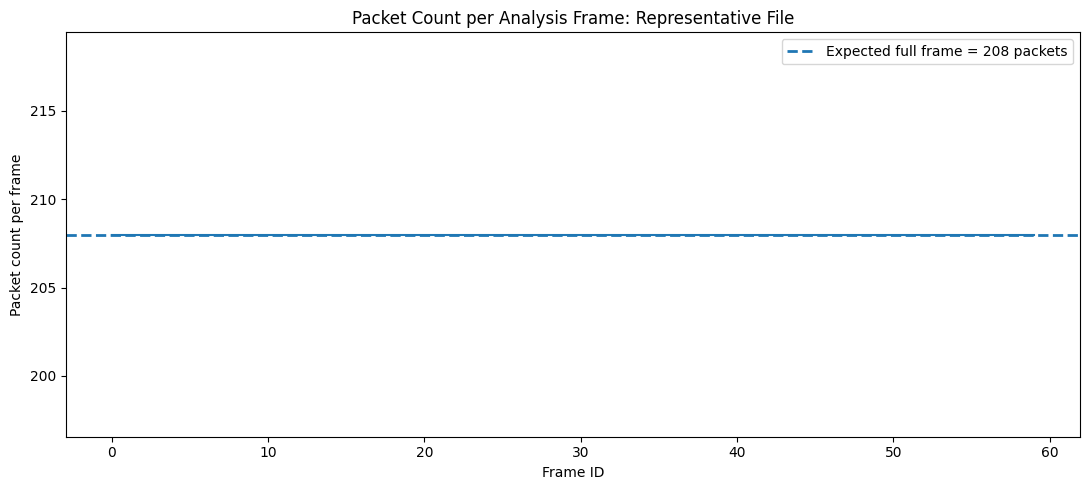

Saved figure: /media/spell/Spell-lab/Lidar/C.Framed Dataset/_analysis_figures/line_packet_per_frame_example.png
Packet per frame summary for example file:


count     60.0
mean     208.0
std        0.0
min      208.0
25%      208.0
50%      208.0
75%      208.0
max      208.0
Name: packet_count, dtype: float64


Unique packet count per frame:


,packet_count,count
0,208,60


In [10]:
# =========================
# PLOT 4: PACKET COUNT PER FRAME FOR EXAMPLE FILE
# =========================

packet_per_frame_example = (
    example_df.groupby("frame_id")["Timestamp"]
    .nunique()
    .reset_index(name="packet_count")
)

plt.figure(figsize=(11, 5))
plt.plot(packet_per_frame_example["frame_id"], packet_per_frame_example["packet_count"], linewidth=1.5)
plt.axhline(EXPECTED_PACKET_PER_FRAME, linestyle="--", linewidth=2, label=f"Expected full frame = {EXPECTED_PACKET_PER_FRAME} packets")
plt.xlabel("Frame ID")
plt.ylabel("Packet count per frame")
plt.title("Packet Count per Analysis Frame: Representative File")
plt.legend()
plt.tight_layout()

fig_path = FIG_DIR / "line_packet_per_frame_example.png"
plt.savefig(fig_path, dpi=300, bbox_inches="tight")
plt.show()

print("Saved figure:", fig_path)
print("Packet per frame summary for example file:")
display(packet_per_frame_example["packet_count"].describe())

print("\nUnique packet count per frame:")
display(packet_per_frame_example["packet_count"].value_counts().sort_index().reset_index().rename(columns={"index": "packet_count", 0: "num_frames"}))

Cell 9 — Histogram/bar final point count per frame

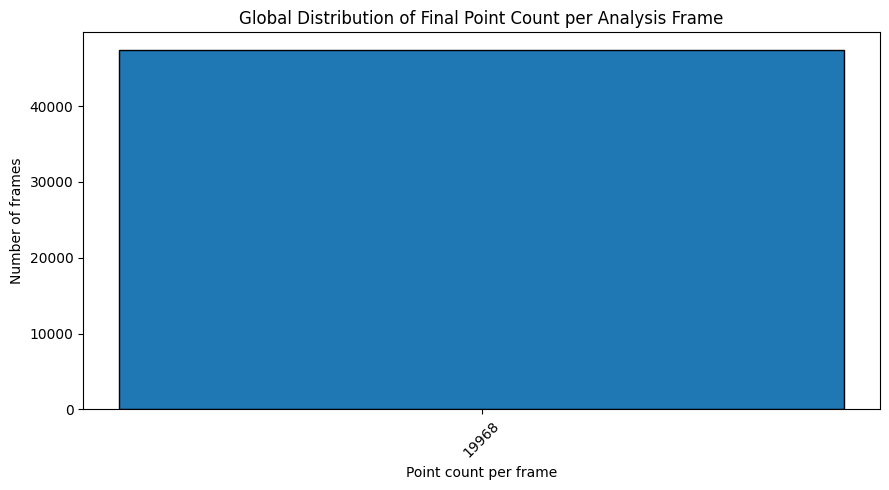

Saved figure: /media/spell/Spell-lab/Lidar/C.Framed Dataset/_analysis_figures/bar_global_point_count_per_frame.png
Global unique point count per frame:


,point_count_per_frame,num_frames
0,19968,47371



Expected point per frame: 19968


In [11]:
# =========================
# PLOT 5: GLOBAL FINAL POINT COUNT PER FRAME
# =========================

point_frame_counts = pd.Series(all_point_per_frame).value_counts().sort_index().reset_index()
point_frame_counts.columns = ["point_count_per_frame", "num_frames"]

plt.figure(figsize=(9, 5))
plt.bar(point_frame_counts["point_count_per_frame"].astype(str), point_frame_counts["num_frames"], edgecolor="black")
plt.xlabel("Point count per frame")
plt.ylabel("Number of frames")
plt.title("Global Distribution of Final Point Count per Analysis Frame")
plt.xticks(rotation=45)
plt.tight_layout()

fig_path = FIG_DIR / "bar_global_point_count_per_frame.png"
plt.savefig(fig_path, dpi=300, bbox_inches="tight")
plt.show()

print("Saved figure:", fig_path)
print("Global unique point count per frame:")
display(point_frame_counts)

print("\nExpected point per frame:", EXPECTED_POINT_PER_FRAME)

In [12]:
# =========================
# SAVE ANALYSIS SUMMARY
# =========================

ANALYSIS_REPORT_DIR = FRAMED_BASE_DIR / "_analysis_reports"
ANALYSIS_REPORT_DIR.mkdir(parents=True, exist_ok=True)

file_summary_path = ANALYSIS_REPORT_DIR / "frame_builder_file_summary.csv"
point_per_packet_path = ANALYSIS_REPORT_DIR / "global_point_per_packet_distribution.csv"
timestamp_diff_path = ANALYSIS_REPORT_DIR / "global_timestamp_diff_distribution.csv"
packet_per_frame_path = ANALYSIS_REPORT_DIR / "global_packet_per_frame_distribution.csv"
point_per_frame_path = ANALYSIS_REPORT_DIR / "global_point_per_frame_distribution.csv"

file_summary_df.to_csv(file_summary_path, index=False, encoding="utf-8", sep=",", lineterminator="\n")

pd.Series(all_point_per_packet).value_counts().sort_index().reset_index().rename(
    columns={"index": "point_per_packet", 0: "count"}
).to_csv(point_per_packet_path, index=False, encoding="utf-8", sep=",", lineterminator="\n")

pd.Series(all_timestamp_diff).value_counts().sort_index().reset_index().rename(
    columns={"index": "timestamp_diff_ns", 0: "count"}
).to_csv(timestamp_diff_path, index=False, encoding="utf-8", sep=",", lineterminator="\n")

pd.Series(all_packet_per_frame).value_counts().sort_index().reset_index().rename(
    columns={"index": "packet_per_frame", 0: "count"}
).to_csv(packet_per_frame_path, index=False, encoding="utf-8", sep=",", lineterminator="\n")

pd.Series(all_point_per_frame).value_counts().sort_index().reset_index().rename(
    columns={"index": "point_per_frame", 0: "count"}
).to_csv(point_per_frame_path, index=False, encoding="utf-8", sep=",", lineterminator="\n")

print("===== ANALYSIS REPORT SAVED =====")
print("File summary              :", file_summary_path)
print("Point per packet dist     :", point_per_packet_path)
print("Timestamp diff dist       :", timestamp_diff_path)
print("Packet per frame dist     :", packet_per_frame_path)
print("Point per frame dist      :", point_per_frame_path)

print("\nFigures saved in:", FIG_DIR)
for p in sorted(FIG_DIR.glob("*.png")):
    print("-", p.name)

===== ANALYSIS REPORT SAVED =====
File summary              : /media/spell/Spell-lab/Lidar/C.Framed Dataset/_analysis_reports/frame_builder_file_summary.csv
Point per packet dist     : /media/spell/Spell-lab/Lidar/C.Framed Dataset/_analysis_reports/global_point_per_packet_distribution.csv
Timestamp diff dist       : /media/spell/Spell-lab/Lidar/C.Framed Dataset/_analysis_reports/global_timestamp_diff_distribution.csv
Packet per frame dist     : /media/spell/Spell-lab/Lidar/C.Framed Dataset/_analysis_reports/global_packet_per_frame_distribution.csv
Point per frame dist      : /media/spell/Spell-lab/Lidar/C.Framed Dataset/_analysis_reports/global_point_per_frame_distribution.csv

Figures saved in: /media/spell/Spell-lab/Lidar/C.Framed Dataset/_analysis_figures
- bar_global_point_count_per_frame.png
- hist_point_per_packet.png
- hist_timestamp_diff_ns.png
- line_packet_per_frame_example.png
- line_point_per_frame_example.png


Saran interpretasi nanti kalau hasilnya ideal:

Histogram point per packet harus dominan/tunggal di 96.

Histogram timestamp diff harus dominan/tunggal di 480000 ns.

Line plot packet per frame harus datar di 208.

Line plot point per frame harus datar di 19968.

Bar chart global point/frame harus dominan/tunggal di 19968.